In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('/content/1) iris.csv',
                 sep=None, engine='python', on_bad_lines='skip')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# Drop species column, keep only numeric features
X = df.select_dtypes(include=np.number)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used:", X.columns.tolist())
print("Scaled shape:", X_scaled.shape)

Features used: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Scaled shape: (150, 4)


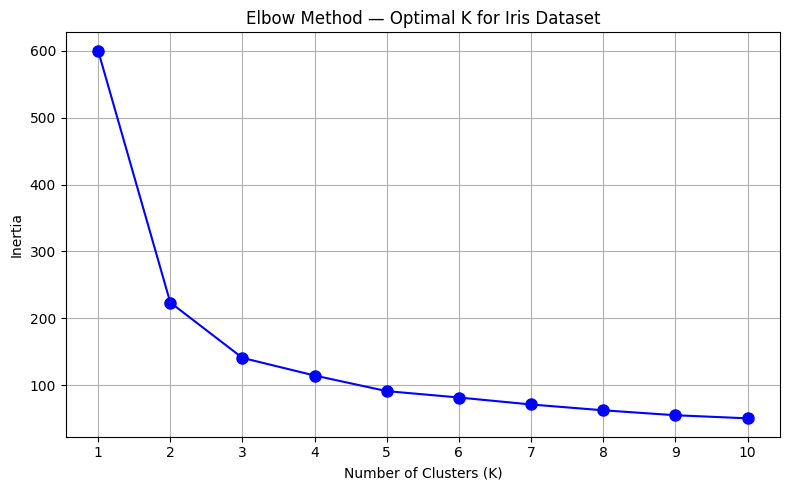

✅ From the elbow plot, optimal K = 3 for Iris dataset


In [3]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K for Iris Dataset')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

print("✅ From the elbow plot, optimal K = 3 for Iris dataset")

In [4]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df['Cluster'].value_counts())

Cluster counts:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


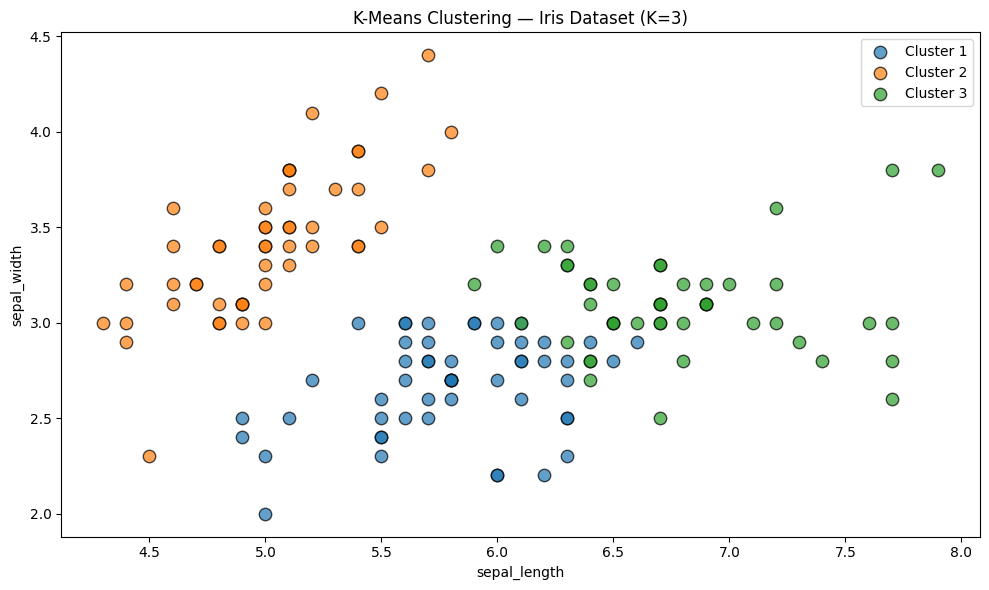

In [5]:
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data.iloc[:, 0],
                cluster_data.iloc[:, 1],
                label=f'Cluster {i+1}',
                alpha=0.7, s=80, edgecolors='black')

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('K-Means Clustering — Iris Dataset (K=3)')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()

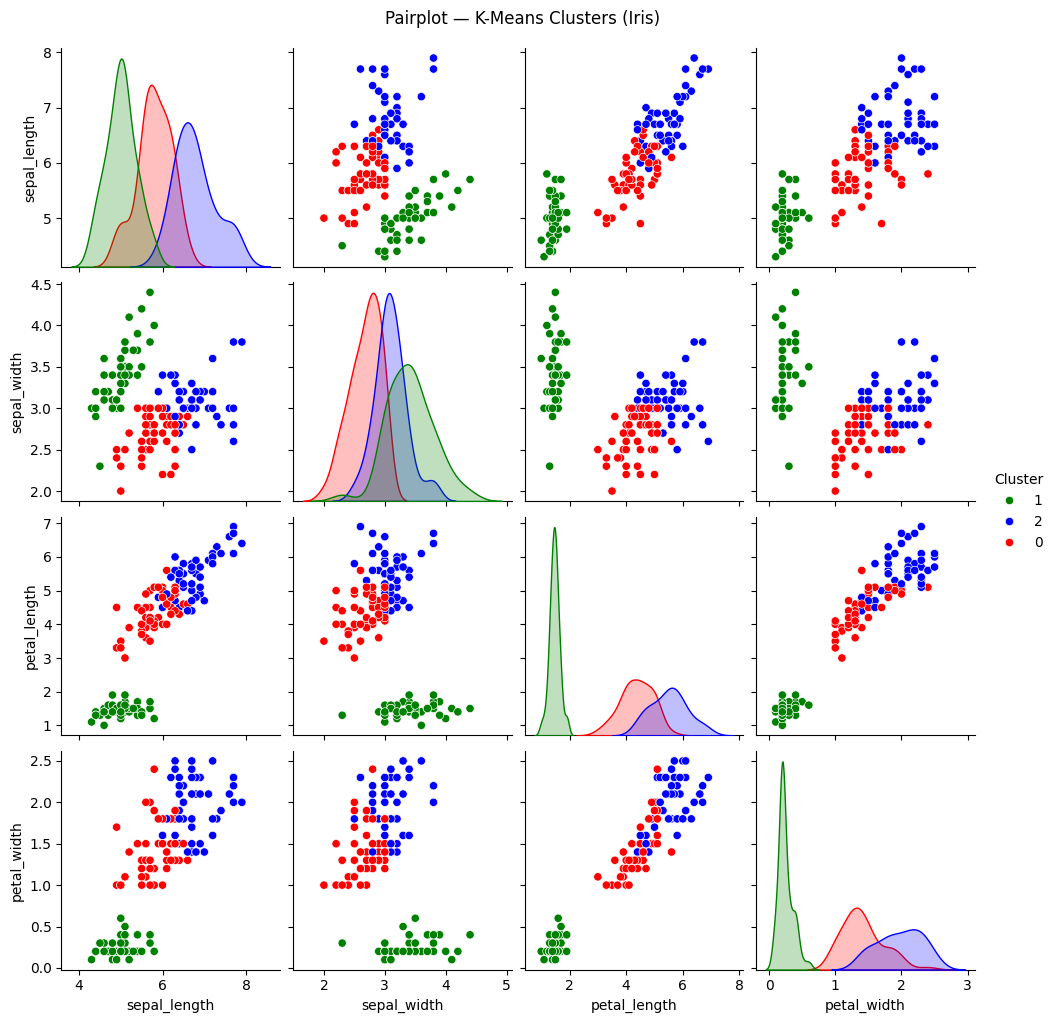

In [6]:
plot_df = df.copy()
plot_df['Cluster'] = plot_df['Cluster'].astype(str)

sns.pairplot(plot_df,
             hue='Cluster',
             vars=X.columns.tolist(),
             palette={'0': 'red', '1': 'green', '2': 'blue'})
plt.suptitle('Pairplot — K-Means Clusters (Iris)', y=1.02)
plt.savefig('kmeans_pairplot.png', dpi=150)
plt.show()

In [7]:
from google.colab import files

files.download('elbow_method.png')
files.download('kmeans_clusters.png')
files.download('kmeans_pairplot.png')
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
